## Downloading with CDSE

In [1]:
# install with
# !pip install terragon-downloader[cdse]

In [1]:
import terragon
import geopandas as gpd
import xarray as xr
from utils import visualize_sat_images, list_of_dicts_to_tree
import rasterio

In [6]:
# we will use the sample data to download a minicube
# other datasets can be found here: https://documentation.dataspace.copernicus.eu/APIs/newSTACcatalogue.html
gdf = gpd.read_file("data/TUM_OTN.geojson")
gdf = gdf.to_crs("EPSG:32632")
arguments = dict(
    shp=gdf,
    collection="sentinel-1-grd",
    bands=["vv", "vh"],
    start_date="2021-09-03",
    end_date="2021-09-04",
    resolution=10,
    save_metadata=["id", "sat:absolute_orbit"]

)
gdf.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### download

In [2]:
# credentials can be created here: https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials
credentials = {"aws_access_key_id": "<your-id>", "aws_secret_access_key": "<your-key>"}
tg = terragon.init("cdse", credentials=credentials)

Finding collections

In [5]:
# explore the CDSE data on their website: https://dataspace.copernicus.eu/data-collections, https://browser.dataspace.copernicus.eu/
collections = tg.retrieve_collections(
    query={"id": "Sentinel.1.*"}, fields=["id", "title"]
)  # filter field with regex and only return wished fields
list_of_dicts_to_tree(collections)

Tree(nodes=(Node(name='Item 1', nodes=(Node(name='id: SENTINEL-1-RTC'), Node(name='title: SENTINEL-1-RTC'))), …

download (with eodata AWS S3 backend)

In [6]:
# cdse is accessed via the stac catalog
ds = tg.create(**arguments)
# or
# items = tg.search(**arguments)
# ds = tg.download(items)
ds

<xarray.Dataset> Size: 13kB
Dimensions:             (y: 18, x: 28, time: 3)
Coordinates:
  * y                   (y) float64 144B 5.326e+06 5.326e+06 ... 5.326e+06
  * x                   (x) float64 224B 6.976e+05 6.976e+05 ... 6.979e+05
  * time                (time) datetime64[ns] 24B 2021-09-04T05:25:55.177676 ...
    id                  (time) <U71 852B 'S1B_IW_GRDH_1SDV_20210904T052555_20...
    sat:absolute_orbit  (time) int64 24B 28544 28544 28544
    spatial_ref         int64 8B 0
Data variables:
    vv                  (time, y, x) float32 6kB nan nan nan nan ... nan nan nan
    vh                  (time, y, x) float32 6kB nan nan nan nan ... nan nan nan
Attributes:
    crs:          EPSG:32632
    data_source:  CDSE
    collection:   sentinel-1-grd

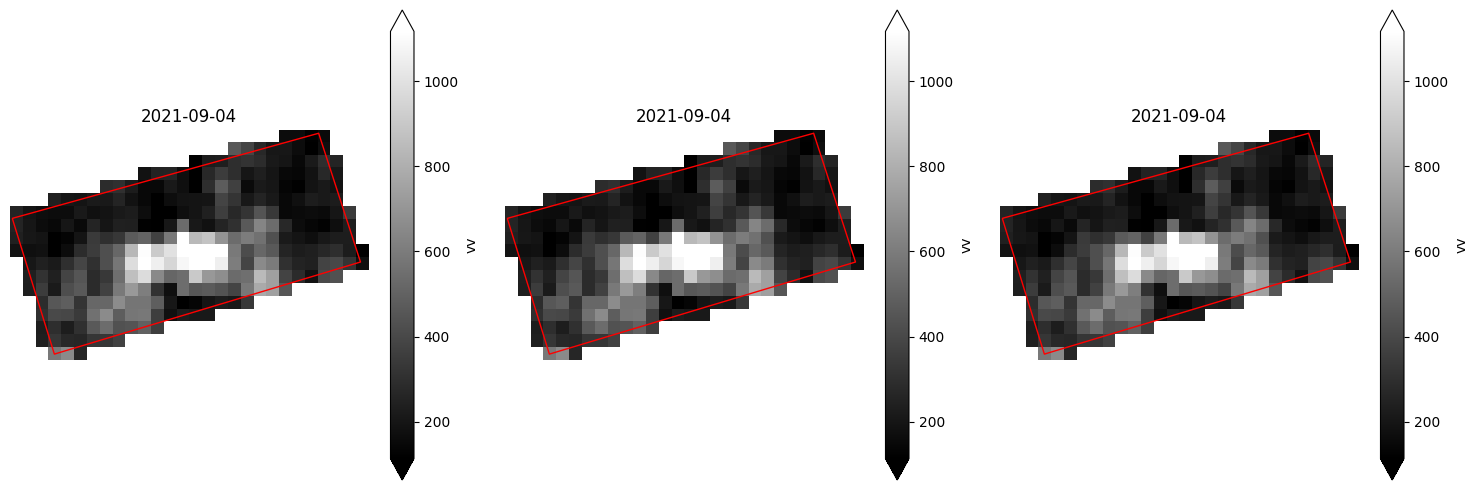

In [11]:
visualize_sat_images(ds, gdf, ['vv'])

In [12]:
# the ouptut of the search is a collection of items
tg.search(**arguments)

[<Item id=S1B_IW_GRDH_1SDV_20210904T052555_20210904T052620_028544_036806_B47F_COG>,
 <Item id=S1B_IW_GRDH_1SDV_20210904T052555_20210904T052620_028544_036806_AB6F_COG>,
 <Item id=S1B_IW_GRDH_1SDV_20210904T052555_20210904T052620_028544_036806_6F3A_COG>]

### Filtering the meta data

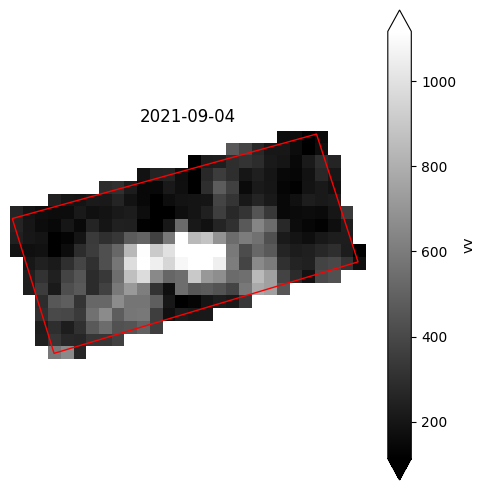

In [14]:
ds = tg.create(**arguments, filter={"id": {"eq": "S1B_IW_GRDH_1SDV_20210904T052555_20210904T052620_028544_036806_B47F_COG"}})
visualize_sat_images(ds, gdf, ['vv'])